In [1]:
import os, sys
os.chdir('../')
os.environ["DPM_TQDM"] = "False"

EDM = os.path.join("edm")
sys.path.insert(0, EDM)
print('done')

done


In [2]:
from backbones.edm import EDM

model = EDM()

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-11 14:58:34.130006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


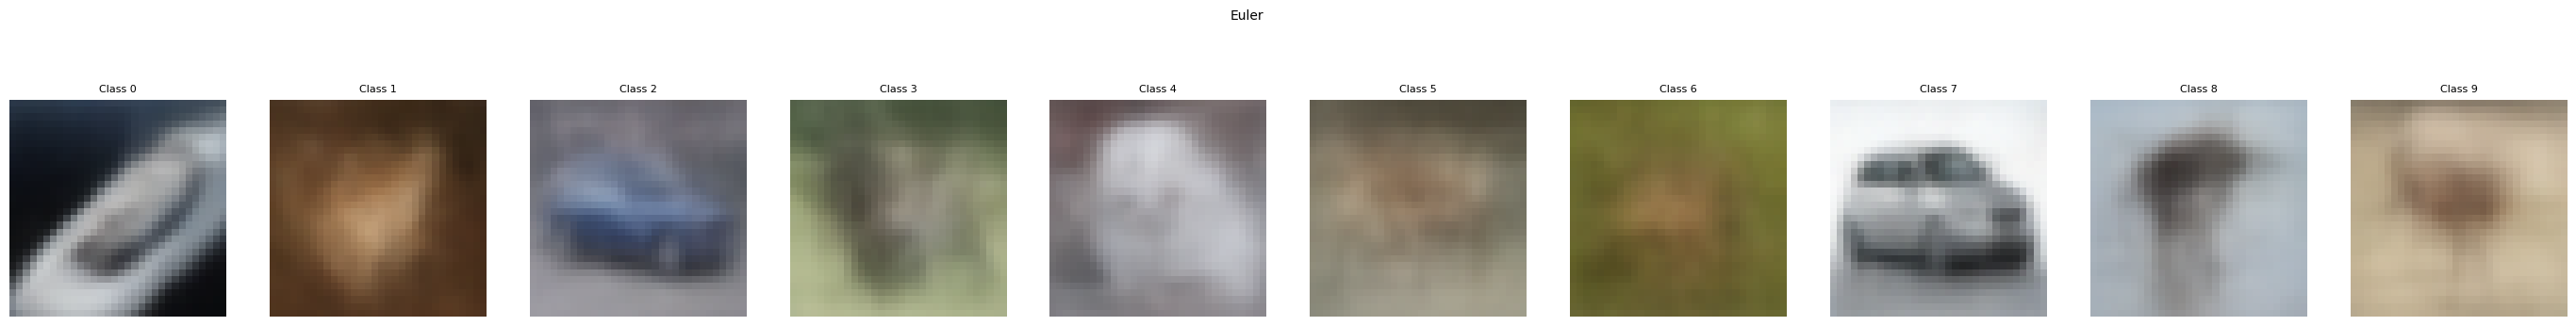

In [12]:
import torch
from solvers.others.euler_solver import Euler_Solver

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule)
seeds = np.random.randint(np.iinfo(np.int32).max, size=(10,))
noises = model.get_noise(seeds=seeds)

NFE = 20
with torch.autocast(device_type='cuda', dtype=torch.float32):
    solver = Euler_Solver(noise_schedule, algorithm_type="noise_prediction", steps=NFE, skip_type="time_uniform")
    euler_latents = solver.sample(noises, model_fn)['samples']
    euler_samples = model.decode_vae(euler_latents, pil_output=True)['pil_output']
    display_class_images(euler_samples, None, display_title='Euler')


In [6]:
noises.dtype

torch.float32